In [1]:
!pip install open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 64.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import cv2
import open3d as o3d
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch 
from torch.utils.data import Dataset
from scipy import stats


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
base_path = "/kaggle/input/kitti-3d-object-detection-dataset"

In [4]:
print(os.listdir(base_path))

['kitti_dbinfos_train.pkl', 'training', 'kitti_infos_train.pkl', 'testing', 'kitti_infos_test.pkl', 'kitti_infos_val.pkl', 'gt_database', 'devkit_object', 'kitti_infos_trainval.pkl']


In [5]:

kitti_path = "/kaggle/input/kitti-3d-object-detection-dataset/training/velodyne"

In [6]:
sample_file = sorted(os.listdir(kitti_path))[0]
sample_path = os.path.join(kitti_path, sample_file)

points = np.fromfile(sample_path, dtype=np.float32).reshape(-1, 4)
points[:5]


array([[1.8324e+01, 4.9000e-02, 8.2900e-01, 0.0000e+00],
       [1.8344e+01, 1.0600e-01, 8.2900e-01, 0.0000e+00],
       [5.1299e+01, 5.0500e-01, 1.9440e+00, 0.0000e+00],
       [1.8317e+01, 2.2100e-01, 8.2900e-01, 0.0000e+00],
       [1.8352e+01, 2.5100e-01, 8.3000e-01, 9.0000e-02]], dtype=float32)

In [7]:
def create_bev(points, x_range=(-40,40), y_range=(-40,40), resolution=0.1):
    mask = (
        (points[:,0] > x_range[0]) & (points[:,0] < x_range[1]) &
        (points[:,1] > y_range[0]) & (points[:,1] < y_range[1])
    )
    pts = points[mask]
    
    x_img = ((pts[:,0] - x_range[0]) / resolution).astype(np.int32)
    y_img = ((pts[:,1] - y_range[0]) / resolution).astype(np.int32)
    
    bev = np.zeros((
        int((x_range[1]-x_range[0])/resolution),
        int((y_range[1]-y_range[0])/resolution)
    ))
    
    bev[x_img, y_img] = 1
    return bev

bev_map = create_bev(points)


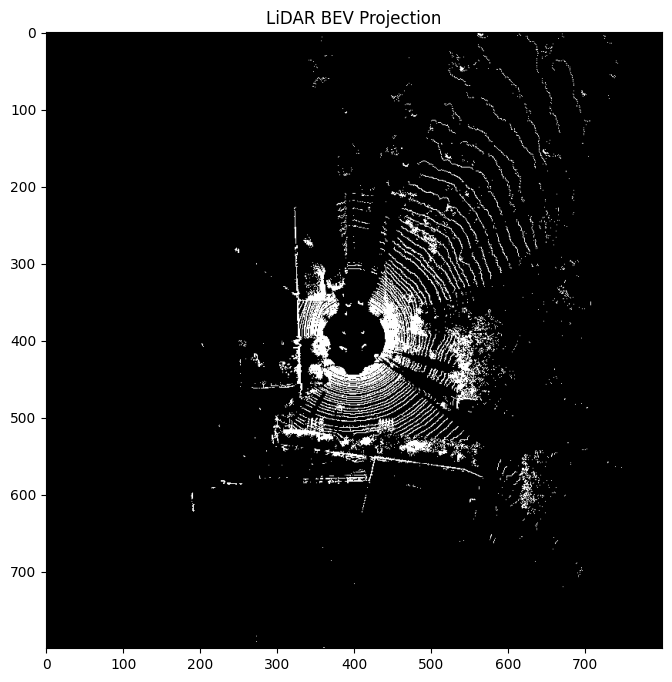

In [8]:
plt.figure(figsize=(8,8))
plt.imshow(bev_map, cmap='gray')
plt.title("LiDAR BEV Projection")
plt.show()

In [9]:
label_path = "/kaggle/input/kitti-3d-object-detection-dataset/training/label_2"

sample_label_file = sorted(os.listdir(label_path))[0]
sample_label_path = os.path.join(label_path, sample_label_file)

with open(sample_label_path, 'r') as f:
    lines = f.readlines()

car_objects = [line for line in lines if line.strip().split(" ")[0] == "Car"]
car_objects[:3]


[]

In [10]:
print(lines[:10])


['Pedestrian 0.00 0 -0.20 712.40 143.00 810.73 307.92 1.89 0.48 1.20 1.84 1.47 8.41 0.01\n']


In [11]:
for file in sorted(os.listdir(label_path)):
    with open(os.path.join(label_path, file), 'r') as f:
        lines = f.readlines()
        cars = [l for l in lines if l.strip().split(" ")[0] == "Car"]
        if len(cars) > 0:
            print("Found Car in:", file)
            print("Number of Cars:", len(cars))
            print("Example:", cars[0])
            sample_label_file = file
            break


Found Car in: 000001.txt
Number of Cars: 1
Example: Car 0.00 0 1.85 387.63 181.54 423.81 203.12 1.67 1.87 3.69 -16.53 2.39 58.49 1.57



In [12]:
velodyne_path = "/kaggle/input/kitti-3d-object-detection-dataset/training/velodyne"

sample_id = "000001"
point_file = os.path.join(velodyne_path, sample_id + ".bin")

points = np.fromfile(point_file, dtype=np.float32).reshape(-1, 4)
points[:5]


array([[49.52 , 22.668,  2.051,  0.   ],
       [49.428, 22.814,  2.05 ,  0.   ],
       [48.096, 22.658,  2.007,  0.05 ],
       [47.813, 22.709,  1.999,  0.   ],
       [48.079, 23.021,  2.012,  0.   ]], dtype=float32)

In [13]:
bev_map = create_bev(points)


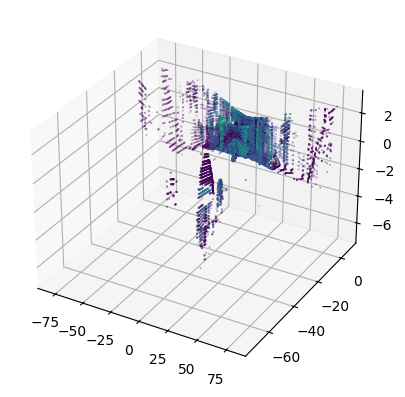

In [14]:

points = np.fromfile('/kaggle/input/kitti-3d-object-detection-dataset/training/velodyne/000002.bin', dtype=np.float32).reshape(-1, 4)  # x, y, z, intensity


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=points[:, 3], cmap='viridis', s=0.1)
plt.show()

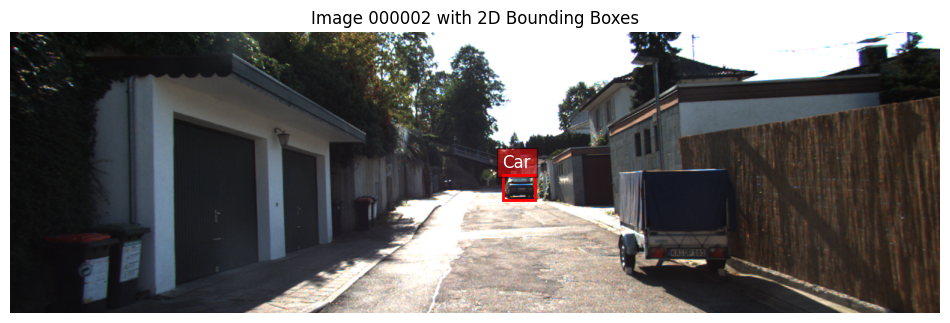

number of the obj in the frame: 2
type
Misc    1
Car     1
Name: count, dtype: int64


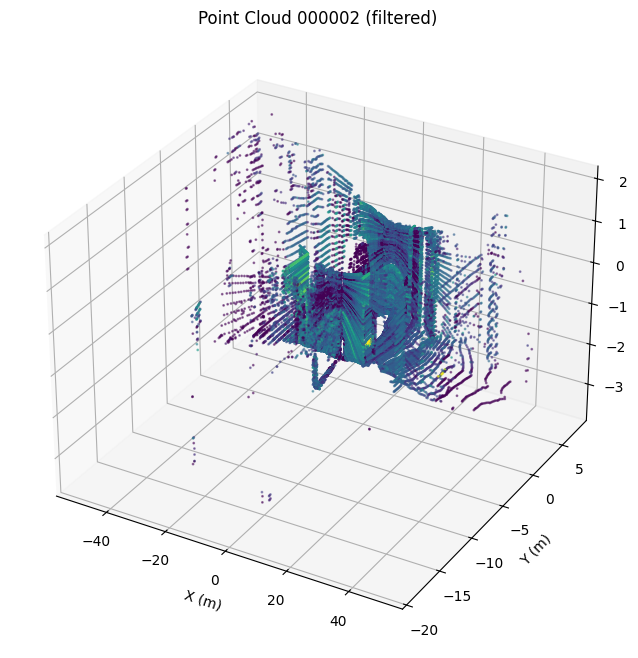

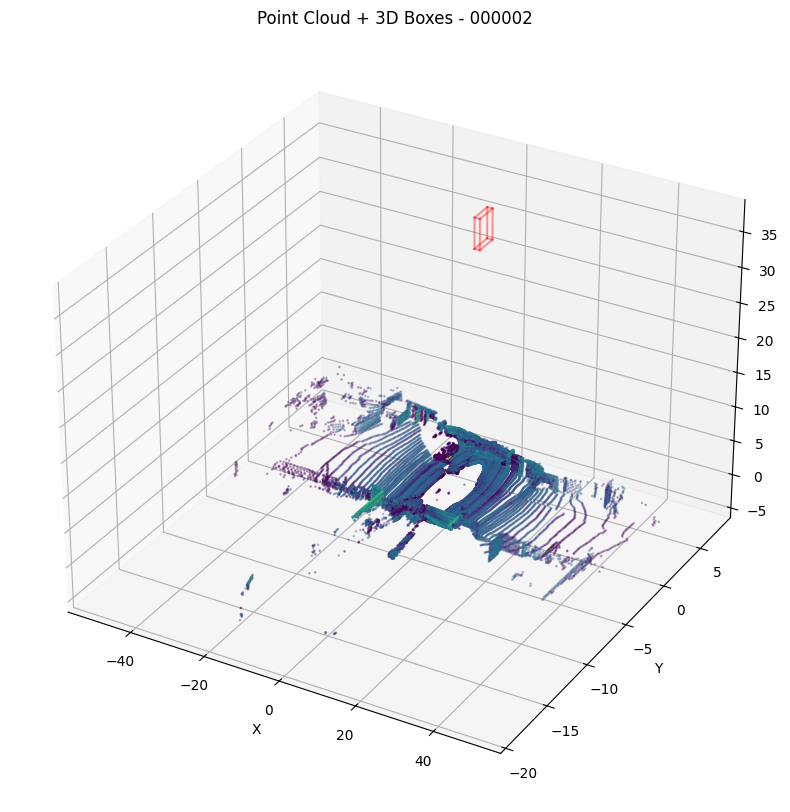

In [15]:
BASE_DIR = Path("/kaggle/input/kitti-3d-object-detection-dataset")  
TRAINING_DIR = BASE_DIR / "training"
IMAGE_DIR = TRAINING_DIR / "image_2"
LABEL_DIR = TRAINING_DIR / "label_2"
VELODYNE_DIR = TRAINING_DIR / "velodyne"


def load_point_cloud(bin_path):
    points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)  # x, y, z, reflectance/intensity
    return points


def load_label(label_path):
    if not os.path.exists(label_path):
        return pd.DataFrame()
    
    columns = ['type', 'truncated', 'occluded', 'alpha', 
               'bbox_left', 'bbox_top', 'bbox_right', 'bbox_bottom',
               'height', 'width', 'length', 'loc_x', 'loc_y', 'loc_z', 'rot_y']
    
    df = pd.read_csv(label_path, sep=' ', header=None, names=columns)
    return df


def plot_3d_box(ax, center, size, rot_y, color='r', alpha=0.3):

    l, w, h = size
    x_c, y_c, z_c = center
    

    dx = np.array([ l/2,  l/2, -l/2, -l/2,  l/2,  l/2, -l/2, -l/2])
    dy = np.array([ w/2, -w/2, -w/2,  w/2,  w/2, -w/2, -w/2,  w/2])
    dz = np.array([ h/2,  h/2,  h/2,  h/2, -h/2, -h/2, -h/2, -h/2])
    

    cos_y = np.cos(rot_y)
    sin_y = np.sin(rot_y)
    x_rot =  cos_y * dx + sin_y * dz
    z_rot = -sin_y * dx + cos_y * dz
    y_rot = dy
    
    x = x_rot + x_c
    y = y_rot + y_c
    z = z_rot + z_c
    

    edges = [
        (0,1), (1,2), (2,3), (3,0),  
        (4,5), (5,6), (6,7), (7,4),  
        (0,4), (1,5), (2,6), (3,7)   
    ]
    
    for edge in edges:
        ax.plot([x[edge[0]], x[edge[1]]],
                [y[edge[0]], y[edge[1]]],
                [z[edge[0]], z[edge[1]]], color=color, alpha=alpha)


frame_id = "000002"  
img_path = IMAGE_DIR / f"{frame_id}.png"
label_path = LABEL_DIR / f"{frame_id}.txt"
velo_path = VELODYNE_DIR / f"{frame_id}.bin"


if os.path.exists(img_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    df_label = load_label(label_path)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(img)
    
    if not df_label.empty:
        for _, row in df_label.iterrows():
            if row['type'] in ['Car', 'Pedestrian', 'Cyclist']:  
                x1, y1, x2, y2 = row['bbox_left'], row['bbox_top'], row['bbox_right'], row['bbox_bottom']
                rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1-10, row['type'], color='white', fontsize=12, bbox=dict(facecolor='red', alpha=0.5))
    
    ax.set_title(f"Image {frame_id} with 2D Bounding Boxes")
    ax.axis('off')
    plt.show()
    
    print(f"number of the obj in the frame: {len(df_label)}")
    print(df_label['type'].value_counts())


if os.path.exists(velo_path):
    points = load_point_cloud(velo_path)
    

    mask = (points[:,0] > -50) & (points[:,0] < 50) & \
           (points[:,1] > -20) & (points[:,1] < 20) & \
           (points[:,2] > -5) & (points[:,2] < 5)
    filtered_points = points[mask]
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(filtered_points[:,0], filtered_points[:,1], filtered_points[:,2],
               c=filtered_points[:,3], cmap='viridis', s=1, alpha=0.5)
    
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title(f"Point Cloud {frame_id} (filtered)")
    plt.show()


if os.path.exists(velo_path) and not df_label.empty:
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(filtered_points[:,0], filtered_points[:,1], filtered_points[:,2],
               c=filtered_points[:,3], cmap='viridis', s=0.8, alpha=0.3)
    
    for _, row in df_label.iterrows():
        if row['type'] in ['Car', 'Pedestrian', 'Cyclist']:
            center = [row['loc_x'], row['loc_y'], row['loc_z']]
            size = [row['length'], row['width'], row['height']]
            color = 'r' if row['type'] == 'Car' else 'g' if row['type'] == 'Pedestrian' else 'b'
            plot_3d_box(ax, center, size, row['rot_y'], color=color, alpha=0.4)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f"Point Cloud + 3D Boxes - {frame_id}")
    plt.show()

All of the Frame: 7481
number of the Obj: 51865
Val Calss:
type
Car               28742
DontCare          11295
Pedestrian         4487
Van                2914
Cyclist            1627
Truck              1094
Misc                973
Tram                511
Person_sitting      222
Name: count, dtype: int64


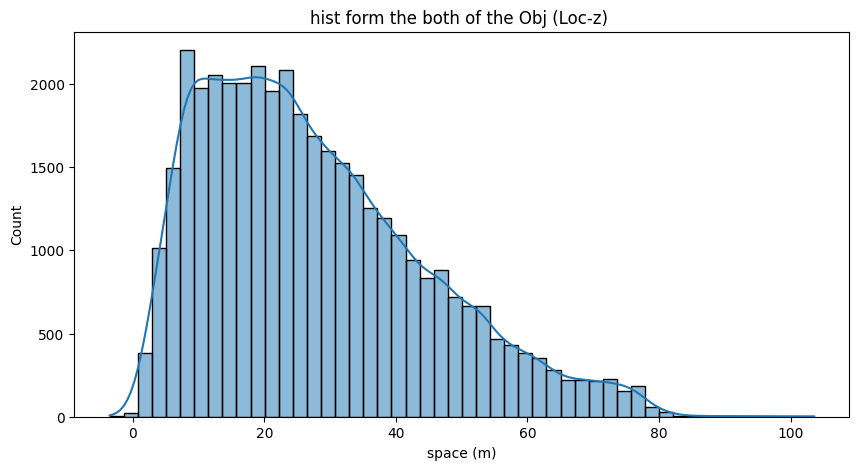

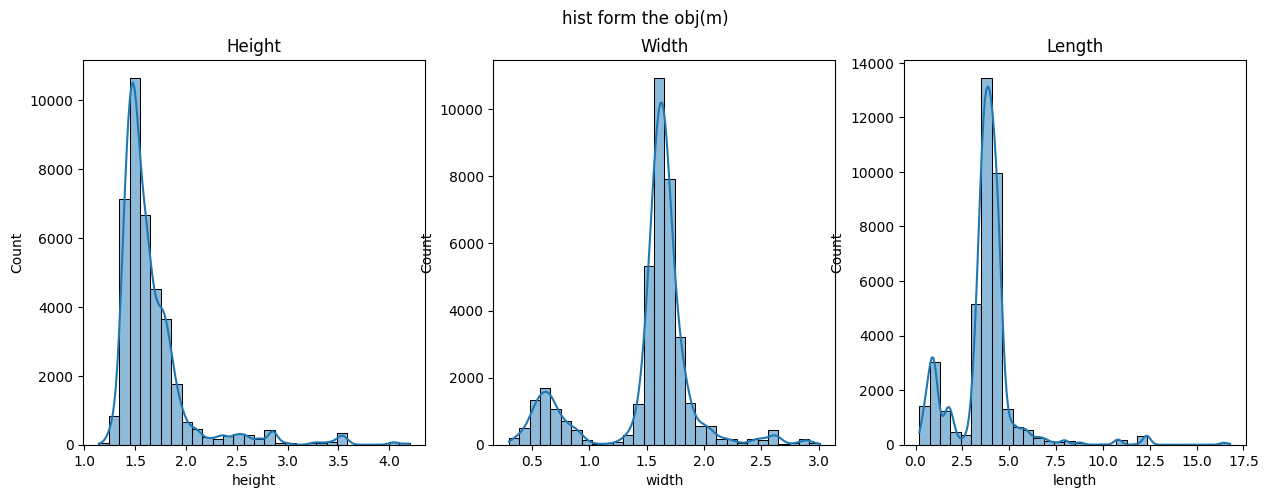

 hard validation:
difficulty
Easy        64.383491
Moderate    24.071120
Hard        11.545389
Name: proportion, dtype: float64
validation occlusion:
occluded
0    18438
1    10680
2     7731
3     2015
Name: count, dtype: int64


/tmp/ipykernel_24/1220317617.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_main['bbox_height'] = df_main['bbox_bottom'] - df_main['bbox_top']
/tmp/ipykernel_24/1220317617.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_main['difficulty'] = 'Hard'


In [16]:
BASE_DIR = Path("/kaggle/input/kitti-3d-object-detection-dataset")
LABEL_DIR = BASE_DIR / "training" / "label_2"


all_labels = []
for label_file in sorted(LABEL_DIR.glob("*.txt")):
    if label_file.stat().st_size == 0:  
        continue
    df = pd.read_csv(label_file, sep=' ', header=None,
                     names=['type', 'truncated', 'occluded', 'alpha', 'bbox_left', 'bbox_top', 'bbox_right', 'bbox_bottom',
                            'height', 'width', 'length', 'loc_x', 'loc_y', 'loc_z', 'rot_y'])
    df['frame'] = label_file.stem
    all_labels.append(df)
    
df_all = pd.concat(all_labels, ignore_index=True)


main_classes = ['Car', 'Pedestrian', 'Cyclist', 'Van', 'Truck']
df_main = df_all[df_all['type'].isin(main_classes)]

print(f"All of the Frame: {len(list(LABEL_DIR.glob('*.txt')))}")
print(f"number of the Obj: {len(df_all)}")
print(f"Val Calss:\n{df_all['type'].value_counts()}")


plt.figure(figsize=(10, 5))
sns.histplot(df_main['loc_z'], bins=50, kde=True)
plt.title('hist form the both of the Obj (Loc-z) ')
plt.xlabel('space (m)')
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(df_main['height'], bins=30, ax=axes[0], kde=True); axes[0].set_title('Height')
sns.histplot(df_main['width'], bins=30, ax=axes[1], kde=True); axes[1].set_title('Width')
sns.histplot(df_main['length'], bins=30, ax=axes[2], kde=True); axes[2].set_title('Length')
plt.suptitle('hist form the obj(m)')
plt.show()


df_main['bbox_height'] = df_main['bbox_bottom'] - df_main['bbox_top']
df_main['difficulty'] = 'Hard'
df_main.loc[df_main['bbox_height'] > 25, 'difficulty'] = 'Moderate'
df_main.loc[df_main['bbox_height'] > 40, 'difficulty'] = 'Easy'

print(f" hard validation:\n{df_main['difficulty'].value_counts(normalize=True) * 100}")


print(f"validation occlusion:\n{df_main['occluded'].value_counts()}")

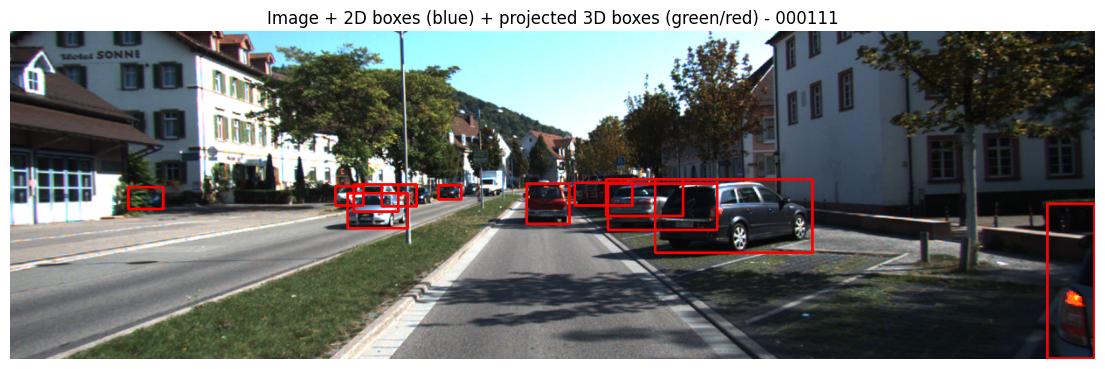

[Open3D WARNING] GLFW Error: Failed to detect any supported platform
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.


error: XDG_RUNTIME_DIR not set in the environment.


In [17]:

BASE_DIR = Path("/kaggle/input/kitti-3d-object-detection-dataset") 
DATA_DIR = BASE_DIR / "training"
IMAGE_DIR = DATA_DIR / "image_2"
LABEL_DIR = DATA_DIR / "label_2"
VELODYNE_DIR = DATA_DIR / "velodyne"
CALIB_DIR = DATA_DIR / "calib"


def load_point_cloud(bin_path):

    return np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)  # [x,y,z,intensity]


def load_calib(calib_path):

    with open(calib_path, 'r') as f:
        lines = f.readlines()
    
    P2 = np.array([float(x) for x in lines[2].strip().split()[1:]]).reshape(3,4)   # (image_2)
    Tr_velo_to_cam = np.array([float(x) for x in lines[5].strip().split()[1:]]).reshape(3,4)
    R0_rect = np.array([float(x) for x in lines[4].strip().split()[1:]]).reshape(3,3)
    
    # Velodyne → rectified camera
    Tr_velo_to_cam_rect = R0_rect @ Tr_velo_to_cam[:,:3]
    Tr_velo_to_cam_rect = np.hstack((Tr_velo_to_cam_rect, Tr_velo_to_cam[:,3].reshape(3,1)))
    
    return P2, Tr_velo_to_cam_rect, R0_rect


def project_3d_to_2d(points_3d, P2, Tr_velo_to_cam_rect):
    ones = np.ones((points_3d.shape[0], 1))
    pts_3d_hom = np.hstack((points_3d[:, :3], ones))  # [x,y,z,1]
    
    # 1. Velodyne → camera
    cam_pts = (Tr_velo_to_cam_rect @ pts_3d_hom.T).T  # [x_c, y_c, z_c]
    

    mask = cam_pts[:, 2] > 0.1
    cam_pts = cam_pts[mask]
    

    img_pts_hom = (P2 @ np.hstack((cam_pts, np.ones((cam_pts.shape[0],1)))).T).T
    img_pts = img_pts_hom[:, :2] / img_pts_hom[:, 2:3]
    
    return img_pts, mask


def corners_3d_from_kitti(center, size, rot_y):

    l, w, h = size      # length, width, height
    x, y, z = center
    

    dx = np.array([l/2, l/2, -l/2, -l/2, l/2, l/2, -l/2, -l/2])
    dy = np.array([w/2, -w/2, -w/2, w/2, w/2, -w/2, -w/2, w/2])
    dz = np.array([h/2, h/2, h/2, h/2, -h/2, -h/2, -h/2, -h/2])
    

    c, s = np.cos(rot_y), np.sin(rot_y)
    x_rot =  c * dx + s * dz
    z_rot = -s * dx + c * dz
    y_rot = dy
    
    corners = np.stack([x + x_rot, y + y_rot, z + z_rot], axis=-1)
    return corners


def draw_projected_box_3d(img, corners_2d, color=(0, 255, 0), thickness=2):

    corners_2d = corners_2d.astype(np.int32)

    for i in range(4):
        cv2.line(img, tuple(corners_2d[i]), tuple(corners_2d[(i+1)%4]), color, thickness)

    for i in range(4):
        cv2.line(img, tuple(corners_2d[i+4]), tuple(corners_2d[(i+1)%4+4]), color, thickness)

    for i in range(4):
        cv2.line(img, tuple(corners_2d[i]), tuple(corners_2d[i+4]), color, thickness)




frame_id = "000111"   # ←  ( 000015, 000067, ...)
img_path    = IMAGE_DIR / f"{frame_id}.png"
label_path  = LABEL_DIR / f"{frame_id}.txt"
velo_path   = VELODYNE_DIR / f"{frame_id}.bin"
calib_path  = CALIB_DIR / f"{frame_id}.txt"


img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
points = load_point_cloud(velo_path)
df_label = pd.read_csv(label_path, sep=' ', header=None, 
                       names=['type','truncated','occluded','alpha','x1','y1','x2','y2',
                              'h','w','l','x','y','z','ry'])

P2, Tr_velo_to_cam_rect, _ = load_calib(calib_path)


img_with_boxes = img.copy()

for _, row in df_label.iterrows():
    if row['type'] not in ['Car', 'Pedestrian', 'Cyclist']:
        continue
        
    # 2D box 
    cv2.rectangle(img_with_boxes, (int(row['x1']), int(row['y1'])), 
                  (int(row['x2']), int(row['y2'])), (255,0,0), 2)
    
    # 3D box ‌
    center = [row['x'], row['y']-row['h']/2, row['z']] 
    size = [row['l'], row['w'], row['h']]
    corners_3d = corners_3d_from_kitti(center, size, row['ry'])
    

    proj_pts, mask = project_3d_to_2d(corners_3d, P2, Tr_velo_to_cam_rect)
    if len(proj_pts) == 8:
        color = (0, 255, 0) if row['type'] == 'Car' else (0, 0, 255)
        draw_projected_box_3d(img_with_boxes, proj_pts, color=color, thickness=2)

plt.figure(figsize=(14, 7))
plt.imshow(img_with_boxes)
plt.title(f"Image + 2D boxes (blue) + projected 3D boxes (green/red) - {frame_id}")
plt.axis('off')
plt.show()


pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points[:, :3])


colors = np.zeros((points.shape[0], 3))
intensity = points[:, 3] / (points[:, 3].max() + 1e-6)
colors[:, 0] = intensity
colors[:, 1] = intensity * 0.5
colors[:, 2] = 1 - intensity
pcd.colors = o3d.utility.Vector3dVector(colors)


geometries = [pcd]

for _, row in df_label.iterrows():
    if row['type'] not in ['Car', 'Pedestrian', 'Cyclist']:
        continue
    center = [row['x'], row['y']-row['h']/2, row['z']]
    size = [row['l'], row['w'], row['h']]
    rot_y = row['ry']
    
    bbox = o3d.geometry.OrientedBoundingBox()
    bbox.center = center
    bbox.R = o3d.geometry.get_rotation_matrix_from_xyz([0, -rot_y, 0])
    bbox.extent = size
    bbox.color = [1, 0, 0] if row['type'] == 'Car' else [0, 1, 0]
    geometries.append(bbox)



o3d.visualization.draw_geometries(geometries,
                                 window_name=f"Open3D - {frame_id}",
                                 width=1200, height=800,
                                 point_show_normal=False)



number of the obj: 12150 (31.26%)


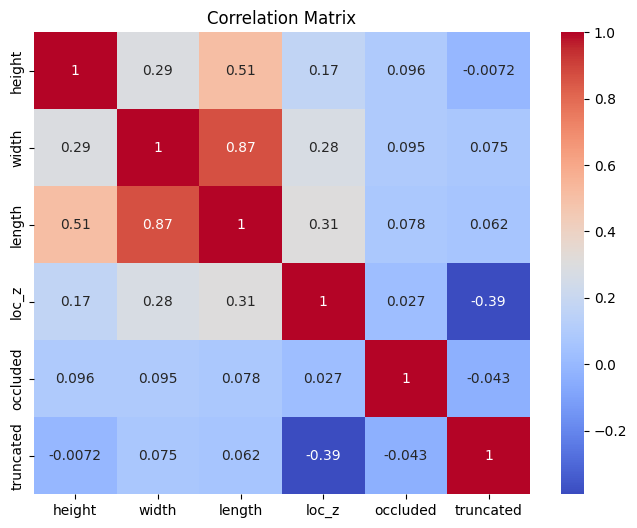

 The most frame with Obj  : 004139 (24 obj)


In [18]:

df_hard = df_main[(df_main['occluded'] >= 2) | (df_main['truncated'] > 0.5)]
print(f"number of the obj: {len(df_hard)} ({len(df_hard)/len(df_main)*100:.2f}%)")


corr = df_main[['height', 'width', 'length', 'loc_z', 'occluded', 'truncated']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


frame_counts = df_all['frame'].value_counts()
max_frame = frame_counts.idxmax()
print(f" The most frame with Obj  : {max_frame} ({frame_counts.max()} obj)")


hard_frame = df_hard['frame'].iloc[0]  


In [19]:
def invert_rigid_transform(Tr):
    Tr_hom = np.vstack((Tr, [0, 0, 0, 1]))
    Tr_inv = np.linalg.inv(Tr_hom)
    return Tr_inv[:3, :]

In [20]:
def points_in_box(points, center, size, rot_y):
    l, w, h = size
    cx, cy, cz = center
    
    
    pts = points[:, :3] - np.array([cx, cy, cz])

    c, s = np.cos(-rot_y), np.sin(-rot_y)
    rot_mat = np.array([
        [c, 0, s],
        [0, 1, 0],
        [-s, 0, c]
    ])
    pts_rot = pts @ rot_mat.T


    mask = (
        (np.abs(pts_rot[:,0]) <= l/2) &
        (np.abs(pts_rot[:,1]) <= w/2) &
        (np.abs(pts_rot[:,2]) <= h/2)
    )

    return mask

In [21]:
def compute_object_statistics(row, points, Tr_velo_to_cam_rect):

    # 1️⃣ convert camera → velodyne
    Tr_inv = invert_rigid_transform(Tr_velo_to_cam_rect)

    center_cam = np.array([row['x'], row['y']-row['h']/2, row['z'], 1])
    center_velo = (Tr_inv @ center_cam)[:3]

    size = [row['l'], row['w'], row['h']]

    # 2️⃣ count LiDAR points
    mask = points_in_box(points, center_velo, size, row['ry'])
    pts_in_box = points[mask]

    num_points = len(pts_in_box)
    volume = row['l'] * row['w'] * row['h']
    density = num_points / (volume + 1e-6)

    # 3️⃣ camera features
    bbox_area = (row['x2'] - row['x1']) * (row['y2'] - row['y1'])
    aspect_ratio = (row['x2'] - row['x1']) / (row['y2'] - row['y1'] + 1e-6)

    return {
        "distance": row['z'],
        "num_lidar_points": num_points,
        "point_density": density,
        "bbox_area": bbox_area,
        "aspect_ratio": aspect_ratio,
        "occluded": row['occluded'],
        "truncated": row['truncated'],
        "volume": volume,
        "class": row['type']
    }


In [22]:
stats = []

frame_ids = sorted(LABEL_DIR.glob("*.txt"))[:200]

for label_file in frame_ids:

    frame_id = label_file.stem
    velo_path = VELODYNE_DIR / f"{frame_id}.bin"
    calib_path = CALIB_DIR / f"{frame_id}.txt"

    if not velo_path.exists():
        continue

    points = load_point_cloud(velo_path)
    df_label = pd.read_csv(label_file, sep=' ', header=None,
                           names=['type','truncated','occluded','alpha',
                                  'x1','y1','x2','y2',
                                  'h','w','l','x','y','z','ry'])

    P2, Tr_velo_to_cam_rect, _ = load_calib(calib_path)

    for _, row in df_label.iterrows():
        if row['type'] not in ['Car','Pedestrian','Cyclist']:
            continue

        obj_stat = compute_object_statistics(row, points, Tr_velo_to_cam_rect)

        # --- Distance (Euclidean range in camera coordinates) ---
        distance = np.sqrt(row['x']**2 + row['y']**2 + row['z']**2)

        # --- 3D bounding box volume ---
        bbox_volume = row['h'] * row['w'] * row['l']

        # --- Image bounding box area ---
        image_bbox_area = (row['x2'] - row['x1']) * (row['y2'] - row['y1'])

        # --- LiDAR density ---
        num_points = obj_stat["num_lidar_points"]
        density = num_points / (bbox_volume + 1e-6)

        # --- Distance-normalized density ---
        density_norm = num_points / (distance**2 + 1e-6)

        stats.append({
            "frame_id": frame_id,
            "class": row['type'],
            "distance": distance,
            "num_lidar_points": num_points,
            "bbox_volume": bbox_volume,
            "image_bbox_area": image_bbox_area,
            "density": density,
            "density_norm": density_norm,
            "occlusion": row['occluded'],
            "truncation": row['truncated']
        })

df_stats = pd.DataFrame(stats)

# Remove invalid samples
df_stats = df_stats[df_stats["num_lidar_points"] > 0]
df_stats = df_stats.replace([np.inf, -np.inf], np.nan)
df_stats = df_stats.dropna()

# Log-transform for modeling
df_stats["log_points"] = np.log(df_stats["num_lidar_points"] + 1e-6)

df_stats.head()


,frame_id,class,distance,num_lidar_points,bbox_volume,image_bbox_area,density,density_norm,occlusion,truncation,log_points
0,000000,Pedestrian,8.733533,322,1.088640,16216.5836,295.781621,4.221589,0,0.0,5.774552
2,000001,Cyclist,46.088134,18,2.254320,371.1524,7.984666,0.008474,3,0.0,2.890372
3,000002,Car,34.601296,19,9.713208,1419.5368,1.956099,0.015870,0,0.0,2.944439
4,000003,Car,13.372767,168,11.271815,11645.0793,14.904431,0.939435,0,0.0,5.123964
5,000004,Car,41.416148,26,10.515824,1967.2148,2.472464,0.015158,0,0.0,3.258097


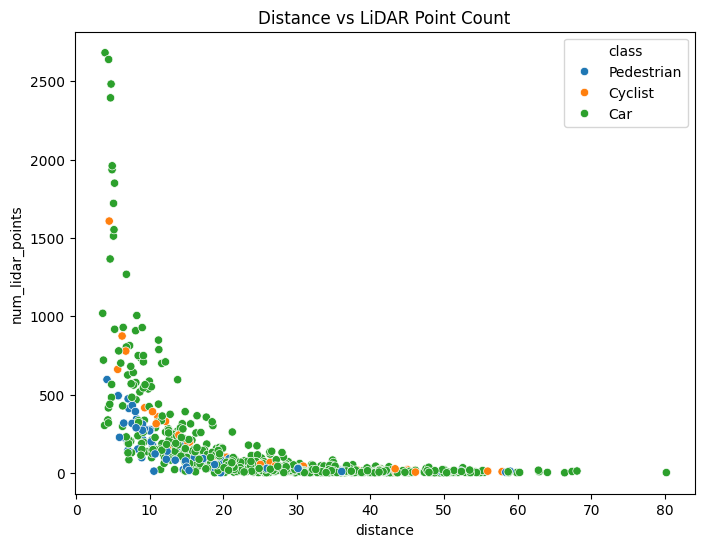

In [23]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_stats, x='distance', y='num_lidar_points', hue='class')
plt.title("Distance vs LiDAR Point Count")
plt.show()


# Quantitative Modeling of LiDAR Signal Degradation  
## Differentiable Formulation

### 3.1 Parametric Distance-Dependent Reliability Model

To enable seamless integration into modern neural sensor-fusion architectures, we reformulate the LiDAR point-cloud degradation as a **differentiable parametric function**.

We retain the empirically well-supported exponential decay model for the expected number of returns:

$$
N(d) = \alpha \exp(-\beta d)
$$

Instead of estimating $\alpha$ and $\beta$ via closed-form linear regression on log-counts, we treat both parameters as **learnable variables** that are optimized end-to-end through gradient-based methods.

### 3.2 Log-Domain Learning Formulation

For improved numerical stability, better-conditioned gradients, and more favorable optimization landscapes, we perform learning directly in the log domain.

Define the observation variable

$$
y = \log N(d)
$$

The model then becomes linear in distance:

$$
y = b - \beta \, d
$$

where

- $b = \log \alpha$ (learnable log-amplitude / intercept)  
- $\beta > 0$   (learnable degradation rate coefficient [m⁻¹])  
- $d$           is provided as an input feature tensor (per-object or per-voxel distance)

The parameters $b$ and $\beta$ are optimized by minimizing the mean squared error (MSE) in log-space:

$$
\mathcal{L}(\theta) = \frac{1}{n} \sum_{i=1}^{n} \bigl( y_i - (b - \beta \, d_i) \bigr)^2
$$

This objective corresponds to **maximum likelihood estimation** under the assumption of homoscedastic Gaussian noise in log-count space:

$$
y_i \;\sim\; \mathcal{N}\bigl( b - \beta \, d_i,\; \sigma^2 \bigr)
$$

### 3.3 Differentiability and Integration into Multi-Modal Fusion Networks

The principal advantage of this formulation — compared to classical offline regression — lies in its full **differentiability** with respect to both model parameters and input distances. This property unlocks several important capabilities in contemporary perception pipelines:

- **End-to-end joint optimization** of reliability modeling together with detection, segmentation, tracking, or prediction backbones  
- **Class-conditioned** or **instance-conditioned** degradation parameters ($\beta_c$ or $\beta_i$)  
- **Per-object dynamic confidence weighting** based on predicted range and learned degradation behavior  
- **Learnable structural priors** for multi-sensor fusion strategies, for example:

$$
w_{\text{LiDAR}}(d) = \exp(-\beta \, d)
$$

$$
w_{\text{Camera}}(d) = 1 - w_{\text{LiDAR}}(d) \quad \text{or} \quad w_{\text{Camera}}(d) = \frac{1}{1 + \exp(\gamma (\beta d - \tau))}
$$

Such soft, distance-aware reliability scores can be directly injected into attention mechanisms, probabilistic fusion layers, uncertainty-aware heads, or BEV feature aggregators.

By making the degradation coefficient $\beta$ (and optionally $\alpha$) a **trainable component** of the perception network, the model can implicitly adapt to:

- different LiDAR types (905 nm vs 1550 nm, spinning vs MEMS/FMCW)  
- varying atmospheric conditions  
- scene-specific object distributions  
- changes in beam divergence, pulse energy, or receiver sensitivity across product generations

This differentiable formulation therefore bridges classical physically-motivated sensor models with the flexibility and representational power of deep learning-based multi-modal perception systems.

In [24]:
import torch 
import torch.nn as nn 
import torch.optim as optim


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
class LogLinearDegradationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.tensor([0.5]))
        self.bias = nn.Parameter(torch.tensor([1.0]))
        self.softplus = nn.Softplus()

    def forward(self, d):
        beta = self.softplus(self.theta)  # ensures β > 0
        y = self.bias - beta * d
        return y, beta


def train_single_factor(distance, log_points, epochs=2000, lr=0.01):

    model = LogLinearDegradationModel().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Convert to numpy
    d = np.array(distance)
    y = np.array(log_points)

    # Normalize distance
    mean_d = d.mean()
    std_d = d.std() + 1e-8
    d_norm = (d - mean_d) / std_d

    d_tensor = torch.tensor(d_norm, dtype=torch.float32).unsqueeze(1).to(device)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device)

    for epoch in range(epochs):
        optimizer.zero_grad()
        output, beta = model(d_tensor)
        loss = criterion(output, y_tensor)
        loss.backward()
        optimizer.step()

    beta_norm = beta.item()
    bias_norm = model.bias.item()

    # Convert parameters back to real distance scale
    beta_real = beta_norm / std_d
    bias_real = bias_norm + (beta_norm * mean_d / std_d)

    # Compute predictions in real scale
    y_pred = bias_real - beta_real * d

    # Compute metrics
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot
    rmse = np.sqrt(np.mean((y - y_pred)**2))

    return beta_real, bias_real, r2, rmse


In [27]:
results_single = []

for cls in df_stats["class"].unique():

    df_cls = df_stats[df_stats["class"] == cls]

    if len(df_cls) < 30:
        continue

    beta, bias, r2, rmse = train_single_factor(
        df_cls["distance"],
        df_cls["log_points"]
    )

    results_single.append({
        "class": cls,
        "beta_distance": beta,
        "bias": bias,
        "R2": r2,
        "RMSE": rmse,
        "num_samples": len(df_cls)
    })

import pandas as pd
df_results_single = pd.DataFrame(results_single)
df_results_single


,class,beta_distance,bias,R2,RMSE,num_samples
0,Pedestrian,0.083457,5.828397,0.666308,0.706709,104
1,Cyclist,0.095286,6.641111,0.828228,0.588796,46
2,Car,0.106061,6.312719,0.650461,1.060191,608


In [28]:
class MultiFactorDegradationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3, 1)

    def forward(self, x):
        return self.linear(x)


In [29]:
def train_multifactor(df_cls, epochs=3000, lr=0.01):

    # Extract variables
    d = df_cls["distance"].values
    occ = df_cls["occlusion"].values
    vol = df_cls["bbox_volume"].values
    y = df_cls["log_points"].values

    log_vol = np.log(vol + 1e-8)

    # Stack feature matrix
    X = np.column_stack([d, occ, log_vol])

    # Normalize each column separately
    mean = X.mean(axis=0)
    std = X.std(axis=0) + 1e-8
    X_norm = (X - mean) / std

    X_tensor = torch.tensor(X_norm, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device)

    model = MultiFactorDegradationModel().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(X_tensor)
        loss = criterion(output, y_tensor)
        loss.backward()
        optimizer.step()

    # Extract learned parameters
    weights_norm = model.linear.weight.detach().cpu().numpy()[0]
    bias_norm = model.linear.bias.item()

    # Convert to real scale
    beta_real = weights_norm / std
    bias_real = bias_norm - np.sum(weights_norm * mean / std)

    # Predictions in real scale
    y_pred = bias_real + X @ beta_real

    # Metrics
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot
    rmse = np.sqrt(np.mean((y - y_pred)**2))

    return beta_real, bias_real, r2, rmse


In [30]:
results_multi = []

for cls in df_stats["class"].unique():

    df_cls = df_stats[df_stats["class"] == cls]

    if len(df_cls) < 30:
        continue

    beta, bias, r2, rmse = train_multifactor(df_cls)

    results_multi.append({
        "class": cls,
        "beta_distance": -beta[0],   # make sign consistent
        "beta_occlusion": -beta[1],
        "beta_log_volume": -beta[2],
        "bias": bias,
        "R2": r2,
        "RMSE": rmse,
        "num_samples": len(df_cls)
    })

df_results_multi = pd.DataFrame(results_multi)
df_results_multi


,class,beta_distance,beta_occlusion,beta_log_volume,bias,R2,RMSE,num_samples
0,Pedestrian,0.085911,0.365245,-0.523259,6.098737,0.752713,0.608371,104
1,Cyclist,0.093358,-0.040326,-0.509309,6.252582,0.841528,0.565542,46
2,Car,0.105736,0.278874,-0.433422,5.545414,0.672112,1.026830,608


In [31]:
def statistical_analysis(df_cls):

    # Target
    y = df_cls['log_points'].values.reshape(-1,1)

    # Design matrix
    X = np.column_stack([
        np.ones(len(df_cls)),
        -df_cls['distance'].values,
        -df_cls['occlusion'].values,
        -df_cls['log_volume'].values
    ])

    n, p = X.shape

    # OLS closed-form
    XtX_inv = np.linalg.inv(X.T @ X)
    theta = XtX_inv @ X.T @ y

    # Residuals
    y_hat = X @ theta
    residuals = y - y_hat

    # Variance estimate
    sigma2 = (residuals.T @ residuals) / (n - p)
    cov_theta = sigma2[0,0] * XtX_inv

    # Standard errors
    se = np.sqrt(np.diag(cov_theta)).reshape(-1,1)

    # t-stats
    t_stats = theta / se

    # p-values (two-tailed)
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n-p))

    # 95% CI
    t_crit = stats.t.ppf(0.975, df=n-p)
    ci_lower = theta - t_crit * se
    ci_upper = theta + t_crit * se

    results = pd.DataFrame({
        'parameter': ['bias','beta_distance','beta_occlusion','beta_log_volume'],
        'estimate': theta.flatten(),
        'std_error': se.flatten(),
        't_value': t_stats.flatten(),
        'p_value': p_values.flatten(),
        'CI_lower': ci_lower.flatten(),
        'CI_upper': ci_upper.flatten()
    })

    return results
